# Plot forecasts

In [14]:
import matplotlib.pyplot as plt 
import pandas as pd 
import os
import matplotlib.dates as mdates
from matplotlib import rcParams
import numpy as np
import matplotlib.ticker as mticker

#### Load forecast results across models

In [3]:
forecasts_path = os.path.join('..', 'out', 'forecasts')
particles = ['NO2', 'O3', 'PM2.5', 'PM10']

# as the column with forecasted values are named something different across model folders, specify it in a dict
model_col = {
    'ARIMA': 'forecast',
    'NHITS': 'NHITS',
    'naive': 'lag24'
}

# read data and convert recordings to pd datetime
df = pd.read_csv(os.path.join('..', 'data', 'aarhus_air_quality.csv'))
df['Recorded'] = pd.to_datetime(df['Recorded'])

# specify test set to get actual observed values
test_size = 96
test_df = df.iloc[-test_size:]

model_dfs = {}
for model_dir, col in model_col.items():
    
    # get all y_true observed values
    combined = {f'{p}_true': test_df[p].reset_index(drop=True) for p in particles}

    # loop over folders with forecasts for each model type and load
    for file in os.listdir(os.path.join(forecasts_path, model_dir)):
        particle = next((p for p in particles if p in file), None)
        if particle is None:
            continue
        path = os.path.join(forecasts_path, model_dir, file)
        df_model = pd.read_csv(path)
        combined[f'{particle}_forecast'] = df_model[col].reset_index(drop=True)
    model_dfs[model_dir] = pd.concat(combined.values(), axis=1, keys=combined.keys())

arima_df = model_dfs['ARIMA']
nhits_df = model_dfs['NHITS']
naive_df = model_dfs['naive']

In [4]:
# inspect df
arima_df.head()

,NO2_true,O3_true,PM2.5_true,PM10_true,NO2_forecast,PM10_forecast,O3_forecast,PM2.5_forecast
0,9.8,57.0,13.8,15.6,10.542055,13.193815,58.394027,11.632261
1,7.8,58.0,13.3,16.9,9.879280,13.157301,58.567144,11.737153
2,4.0,59.0,13.6,17.0,9.392675,13.103792,58.163117,11.644865
3,4.4,61.0,15.6,17.9,8.897918,12.930702,59.231213,11.518109
4,3.7,61.0,15.0,17.5,8.503230,12.879156,59.202300,11.380209


In [5]:
# define train and test sizes
test_size = 96
train_df = df.iloc[:-test_size]
test_df  = df.iloc[-test_size:]

#### Plot forecasts for hold-out test set

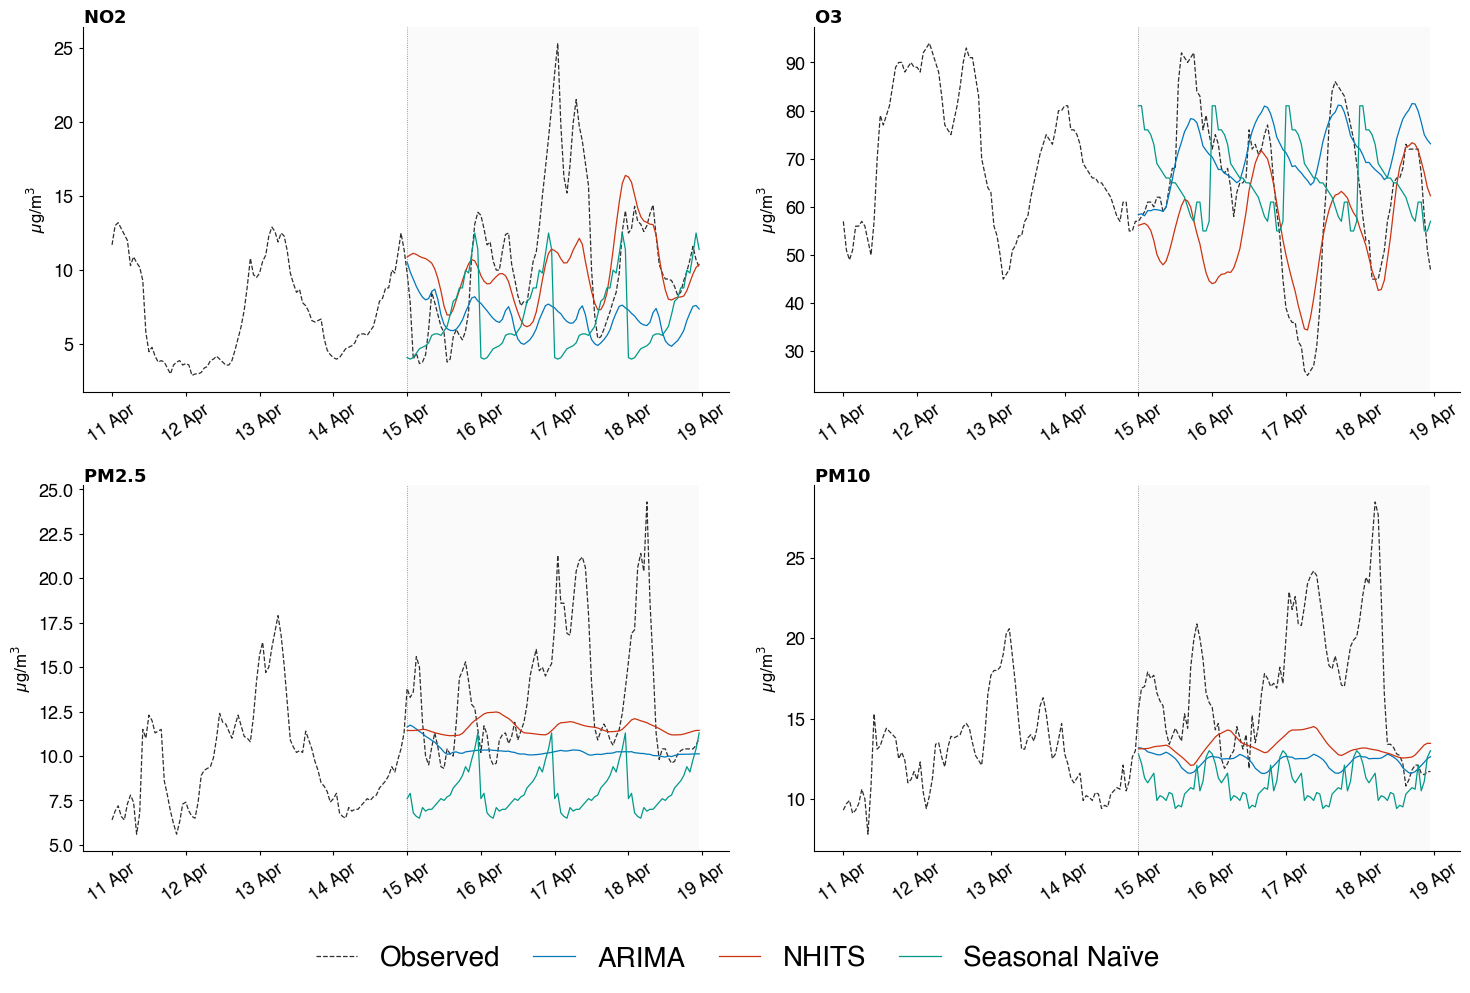

In [8]:

# set plt style configs
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial'],
    'font.size': 15,
    'axes.linewidth': 0.8,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 20,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

# specify colors
colors = {
    'True':  '#2E2E2E',
    'ARIMA': '#0077BB',
    'NHITS': '#CC3311',
    'Naive': '#009988',
}

units = {
    'NO2':   'µg/m$^{3}$',
    'O3':    'µg/m$^{3}$',
    'PM2.5': 'µg/m$^{3}$',
    'PM10':  'µg/m$^{3}$',
}

n_train_hours = 4 * 24
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# plot line for each particle and for each model in a 2x2 grid
for i, p in enumerate(particles):
    ax = axes[i]

    all_dates = pd.concat([train_df['Recorded'].iloc[-n_train_hours:],
                           test_df['Recorded']]).reset_index(drop=True)
    all_vals  = pd.concat([train_df[p].iloc[-n_train_hours:],
                           test_df[p]]).reset_index(drop=True)
    test_dates = test_df['Recorded'].reset_index(drop=True)

    lines = [
        ax.plot(all_dates, all_vals,                    color=colors['True'],  linewidth=0.9, label='Observed', linestyle='--')[0],
        ax.plot(test_dates, arima_df[f'{p}_forecast'],  color=colors['ARIMA'], linewidth=0.9, label='ARIMA')[0],
        ax.plot(test_dates, nhits_df[f'{p}_forecast'],  color=colors['NHITS'], linewidth=0.9, label='NHITS')[0],
        ax.plot(test_dates, naive_df[f'{p}_forecast'],  color=colors['Naive'], linewidth=0.9, label='Naïve')[0],
    ]

    ax.axvspan(test_dates.iloc[0], test_dates.iloc[-1], alpha=0.04, color='gray', linewidth=0)
    ax.axvline(test_dates.iloc[0], color='gray', linestyle=':', linewidth=0.6)

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylabel(units[p])
    ax.set_title(f'$\\bf{{{p.replace(".", chr(46))}}}$', loc='left', pad=3)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.legend(lines, ['Observed', 'ARIMA', 'NHITS', 'Seasonal Naïve'],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01),
           columnspacing=1.2, handlelength=1.5)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join('..', 'out', 'plots', 'forecast_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Plot model residuals over time for hold out test set

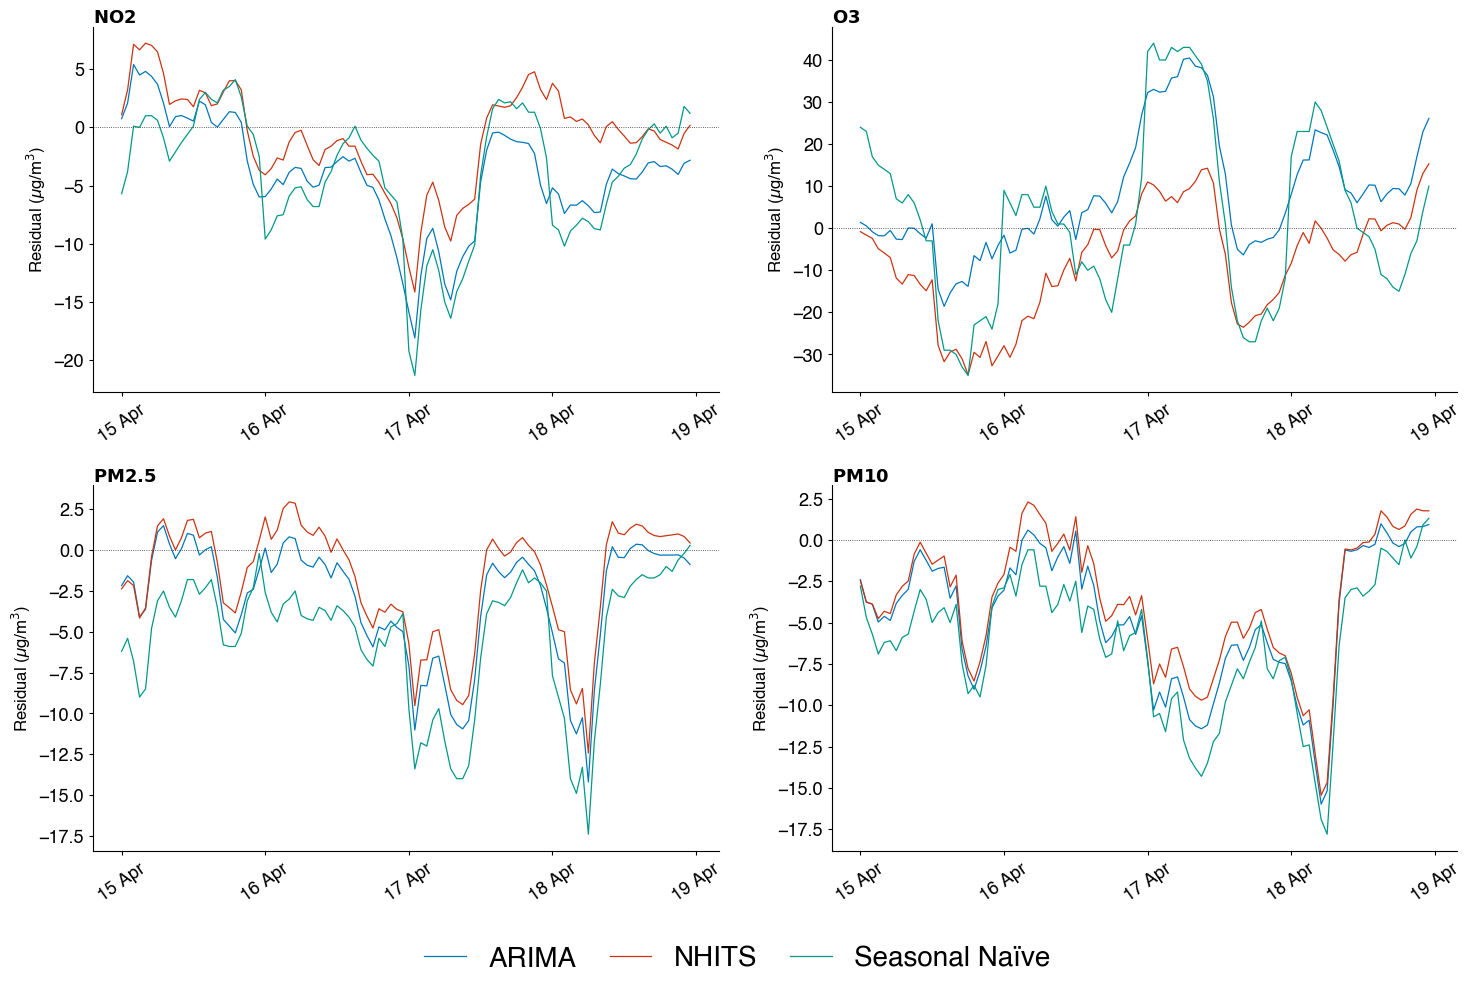

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, p in enumerate(particles):
    ax = axes[i]

    lines = []
    for model_name, mdf, color in [('ARIMA', arima_df, colors['ARIMA']),
                                    ('NHITS', nhits_df, colors['NHITS']),
                                    ('Naïve', naive_df, colors['Naive'])]:
        diff = mdf[f'{p}_forecast'].values - mdf[f'{p}_true'].values
        lines.append(ax.plot(test_dates, diff, color=color, linewidth=0.9, label=model_name)[0])

    ax.axhline(0, color='#2E2E2E', linewidth=0.6, linestyle=':')
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylabel(f'Residual ({units[p]})')
    ax.set_title(f'$\\bf{{{p.replace(".", chr(46))}}}$', loc='left', pad=3)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.legend(lines, ['ARIMA', 'NHITS', 'Seasonal Naïve'],
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.01),
           columnspacing=1.2, handlelength=1.5)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join('..', 'out', 'plots', 'residuals.png'), dpi=600, bbox_inches='tight')
plt.show()

#### Calculate SMAPE and MAE results for forecasts

In [12]:
def smape_array(actual, forecast):
    return np.abs(forecast - actual) / ((np.abs(actual) + np.abs(forecast)) / 2)

smape_scores = {}
smape_sd     = {}
mae_scores   = {}
mae_sd       = {}

for model_name, mdf in [('ARIMA', arima_df), ('NHITS', nhits_df), ('naive', naive_df)]:
    smape_scores[model_name] = {}
    smape_sd[model_name]     = {}
    mae_scores[model_name]   = {}
    mae_sd[model_name]       = {}
    for p in particles:
        actual   = mdf[f'{p}_true'].values
        forecast = mdf[f'{p}_forecast'].values

        et = smape_array(actual, forecast)
        smape_scores[model_name][p] = round(np.mean(et), 2)
        smape_sd[model_name][p]     = round(np.std(et, ddof=1), 2)

        ae = np.abs(actual - forecast)
        mae_scores[model_name][p] = round(np.mean(ae), 2)
        mae_sd[model_name][p]     = round(np.std(ae, ddof=1), 2)

smape_df    = pd.DataFrame(smape_scores)
smape_sd_df = pd.DataFrame(smape_sd)
mae_df      = pd.DataFrame(mae_scores)
mae_sd_df   = pd.DataFrame(mae_sd)

print("SMAPE (mean):\n", smape_df)
print("\nSMAPE (SD):\n", smape_sd_df)
print("\nMAE:\n", mae_df)
print("\nMAE (SD):\n", mae_sd_df)

SMAPE (mean):
        ARIMA  NHITS  naive
NO2     0.50   0.31   0.51
O3      0.19   0.20   0.27
PM2.5   0.24   0.20   0.47
PM10    0.30   0.26   0.42

SMAPE (SD):
        ARIMA  NHITS  naive
NO2     0.27   0.23   0.40
O3      0.23   0.15   0.23
PM2.5   0.22   0.17   0.28
PM10    0.21   0.18   0.22

MAE:
        ARIMA  NHITS  naive
NO2     4.88   3.27   4.86
O3     11.45  11.84  16.89
PM2.5   3.25   2.79   5.35
PM10    4.84   4.28   6.25

MAE (SD):
        ARIMA  NHITS  naive
NO2     3.78   2.81   4.65
O3     11.29   9.71  12.35
PM2.5   3.45   2.77   4.02
PM10    3.92   3.48   4.02


### Plot for client - communication section

In [13]:
# define the best perfomring models per pollutant
best_performing = {'NO2': nhits_df['NO2_forecast'],
                   'O3': arima_df['O3_forecast'],
                   'PM2.5': nhits_df['PM2.5_forecast'],
                   'PM10': nhits_df['PM10_forecast']
}

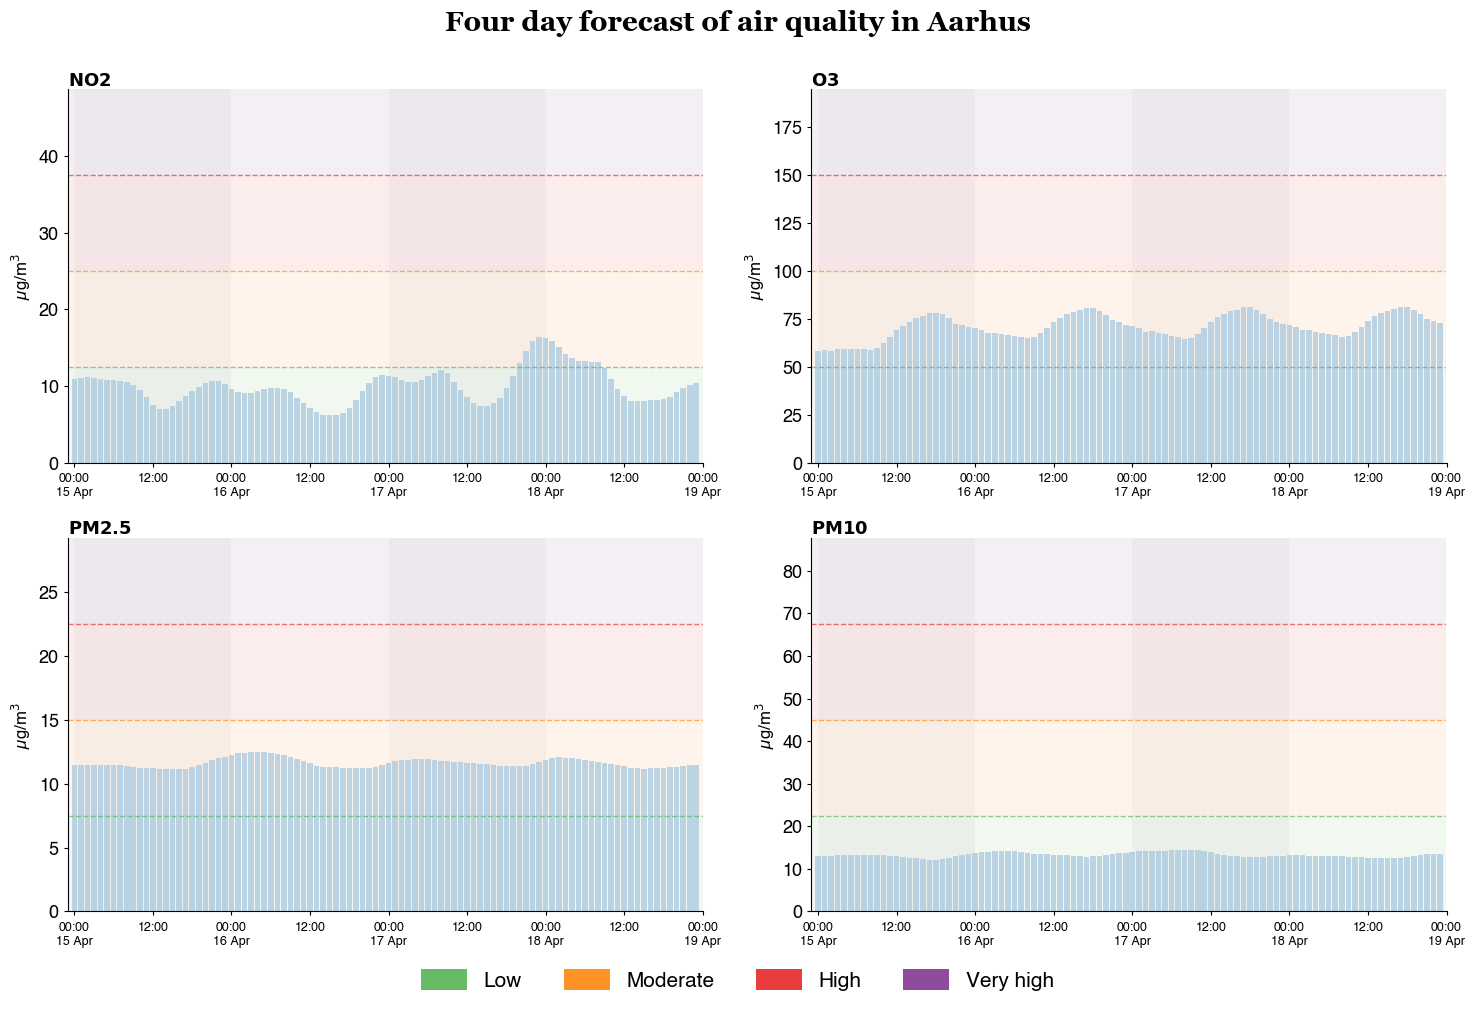

In [15]:
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial'],
    'font.size': 15,
    'axes.linewidth': 0.8,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

units = {
    'NO2':   'µg/m$^{3}$',
    'O3':    'µg/m$^{3}$',
    'PM2.5': 'µg/m$^{3}$',
    'PM10':  'µg/m$^{3}$',
}

model_labels = {
    'NO2':   'NHITS',
    'O3':    'ARIMA',
    'PM2.5': 'NHITS',
    'PM10':  'NHITS',
}

thresholds = {
    'PM2.5': [(7.5,  ''), (15.0, ''), (22.5, '')],
    'PM10':  [(22.5, ''), (45.0, ''), (67.5, '')],
    'NO2':   [(12.5, ''), (25.0, ''), (37.5, '')],
    'O3':    [(50,   ''), (100,  ''), (150,  '')],
}

threshold_colors = ['#4DAF4A', '#FF7F00', '#E41A1C']
level_names      = ['Low', 'Moderate', 'High', 'Very high']
level_colors     = ['#4DAF4A', '#FF7F00', '#E41A1C', '#7B2D8B']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, p in enumerate(particles):
    ax = axes[i]

    test_dates = test_df['Recorded'].reset_index(drop=True)
    values = best_performing[p].reset_index(drop=True)

    # Set ylim early so bands fill correctly
    y_top = max(values.max(), thresholds[p][-1][0]) * 1.3
    ax.set_ylim(bottom=0, top=y_top)

    # Shaded background bands
    band_boundaries = [0] + [val for val, _ in thresholds[p]] + [y_top]
    for lo, hi, col in zip(band_boundaries[:-1], band_boundaries[1:], level_colors):
        ax.axhspan(lo, hi, color=col, alpha=0.08, linewidth=0)

    # Alternating day shading
    days = test_dates.dt.normalize().unique()
    for j, day in enumerate(days):
        if j % 2 == 0:
            ax.axvspan(day, day + pd.Timedelta(days=1), color='gray', alpha=0.06, linewidth=0)

    # Bar plot
    bar_width = (test_dates.iloc[1] - test_dates.iloc[0]).total_seconds() / 86400 * 0.85
    ax.bar(test_dates, values, width=bar_width, color='#A8C8E0', alpha=0.75, linewidth=0, align='center')

    # Threshold lines
    for (val, _), col in zip(thresholds[p], threshold_colors):
        ax.axhline(val, color=col, linestyle='--', linewidth=1.0, alpha=0.6)

    # X-axis ticks
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))

    def make_formatter(dates):
        def fmt(x, pos):
            dt = mdates.num2date(x)
            if dt.hour == 0:
                return dt.strftime('00:00\n%d %b')
            else:
                return '12:00'
        return fmt

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(make_formatter(test_dates)))
    ax.tick_params(axis='x', which='major', rotation=0, pad=4, labelsize=9)

    ax.set_ylabel(units[p])
    ax.set_title(f'$\\bf{{{p.replace(".", chr(46))}}}$', loc='left', pad=3)
    ax.set_xlim(test_dates.iloc[0]  - pd.Timedelta(hours=1),
                test_dates.iloc[-1] + pd.Timedelta(hours=1))

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# Shared legend
threshold_handles = [
    plt.Rectangle((0, 0), 1.6, 0.8, fc=col, alpha=0.85, linewidth=0)
    for col in level_colors
]

fig.legend(
    handles=threshold_handles,
    labels=level_names,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.0),
    fontsize=15,
    frameon=False,
    columnspacing=2.0,
    handlelength=2.2,
    handleheight=1.2,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.suptitle('Four day forecast of air quality in Aarhus', y=1.0,
             fontsize=20, fontweight='bold', fontfamily='Georgia')
plt.savefig(os.path.join('..', 'out', 'plots', 'communation_forecast_plot.png'), dpi=600, bbox_inches='tight')
plt.show()